# Experimet: No Skip Connections

In [1]:
# imports
import torch
import numpy as np
import torchvision
from torchvision.datasets import CIFAR10
from torchvision.transforms import ToTensor
from torch.utils.data.sampler import SubsetRandomSampler
from torch.utils.data.dataloader import DataLoader
import matplotlib.pyplot as plt
%matplotlib inline

## Initializing Datasets & DataLoaders¶

In [2]:
from torchvision import datasets, transforms

# statistics for CIFAR10 for the ResNet model preprocessing
mean = (0.4914, 0.4822, 0.4465)
std = (0.2023, 0.1994, 0.2010)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# get cifar10 datatset, both train and test
train_dataset = CIFAR10(root='/data', download=True, train=True,transform=train_transform)
test_dataset = CIFAR10(root='/data', download=True, train=False,transform=test_transform)
len(train_dataset), len(test_dataset)

C:\Users\shehe\projects\ai-paper-reproductions\resnet\venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


(50000, 10000)

In [3]:
# global random seed for all experiments to ensure reproducibility
seed = 42
torch.manual_seed(seed)
g = torch.Generator()
g.manual_seed(seed)

In [4]:
from torch.utils.data import random_split

val_size = 10000
train_size = len(train_dataset) - val_size

train_ds, val_ds = random_split(train_dataset, [train_size, val_size], generator=g)

In [5]:
# DataLoaders
from torch.utils.data import DataLoader

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=0, generator=g)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=True, num_workers=0, generator=g)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=0)

# check
images, labels = next(iter(train_loader))
print(images.shape, labels.shape)

images, labels = next(iter(test_loader))
print(images.shape, labels.shape)

torch.Size([128, 3, 32, 32]) torch.Size([128])
torch.Size([128, 3, 32, 32]) torch.Size([128])


## Model Setup

In [6]:
# get the model
import sys
import os

# Adds the parent directory to the python path
sys.path.append(os.path.abspath('..'))
from models.resnet import resnet18
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Experiment: No Skip Connections and CIFAR10 Stem

### Training Components

In [7]:
from torch import nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR

# model creation
no_skip_model = resnet18(num_classes=10, stem_type='cifar10',use_skip=True)
no_skip_model = no_skip_model.to(device)

# loss function
criterion = nn.CrossEntropyLoss()

# optimizer
optimizer = optim.SGD(
    no_skip_model.parameters(),
    lr=0.1,
    momentum=0.9,
    weight_decay=1e-4
)

# scheduler
num_epochs = 15
scheduler = StepLR(optimizer, step_size=5, gamma=0.1)

def recorded_time(elapsed_time):
    minutes = int(elapsed_time // 60)
    seconds = round((elapsed_time / 60 - minutes) * 60)
    print(f"time: {minutes}m {seconds}s")

## Training and Validation

In [8]:
from models.resnet import fit
from time import time

# training
start_time = time() # start the timer
history = fit(
    no_skip_model,
    num_epochs,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    device
)
elapsed = time() - start_time    
recorded_time(elapsed)

Epoch 1/15:
	Train   Loss: 2.0259 | Train   Acc: 0.2975
	Val     Loss: 1.6176   | Val     Acc: 0.3966
Epoch 2/15:
	Train   Loss: 1.5065 | Train   Acc: 0.4367
	Val     Loss: 1.3774   | Val     Acc: 0.4996
Epoch 3/15:
	Train   Loss: 1.2585 | Train   Acc: 0.5409
	Val     Loss: 1.2512   | Val     Acc: 0.5476
Epoch 4/15:
	Train   Loss: 1.0747 | Train   Acc: 0.6148
	Val     Loss: 1.0094   | Val     Acc: 0.6430
Epoch 5/15:
	Train   Loss: 0.9057 | Train   Acc: 0.6784
	Val     Loss: 0.8937   | Val     Acc: 0.6878
Epoch 6/15:
	Train   Loss: 0.6918 | Train   Acc: 0.7562
	Val     Loss: 0.6743   | Val     Acc: 0.7608
Epoch 7/15:
	Train   Loss: 0.6369 | Train   Acc: 0.7774
	Val     Loss: 0.6466   | Val     Acc: 0.7743
Epoch 8/15:
	Train   Loss: 0.6029 | Train   Acc: 0.7866
	Val     Loss: 0.6342   | Val     Acc: 0.7770
Epoch 9/15:
	Train   Loss: 0.5765 | Train   Acc: 0.7955
	Val     Loss: 0.6076   | Val     Acc: 0.7866
Epoch 10/15:
	Train   Loss: 0.5493 | Train   Acc: 0.8065
	Val     Loss: 0.5806   |

### Test

In [9]:
from models.resnet import evaluate

# test
result = evaluate(no_skip_model, test_loader, criterion, device)
print(f"Test loss: {result[0]:.4f}, Test acc: {result[1]:.4f}")

Test loss: 0.5450, Test acc: 0.8135


## Results

In [10]:
# make data of training and validtion for loss and accuracy plots

train_metrics = history['training']
val_metrics = history['validation']

train_loss = [ loss for loss,_ in train_metrics]
train_acc = [ acc for _,acc in train_metrics]

val_loss = [ loss for loss,_ in val_metrics]
val_acc = [ acc for _,acc in val_metrics]
    

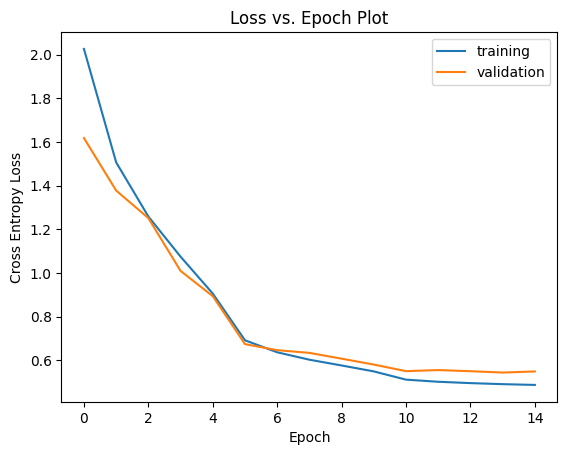

In [11]:
import matplotlib.pyplot as plt
# make plot for loss

plt.plot(train_loss, label="training")
plt.plot(val_loss, label="validation")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.title("Loss vs. Epoch Plot")
plt.legend()
plt.savefig('./images/baseline_loss_plot.png')
plt.show()

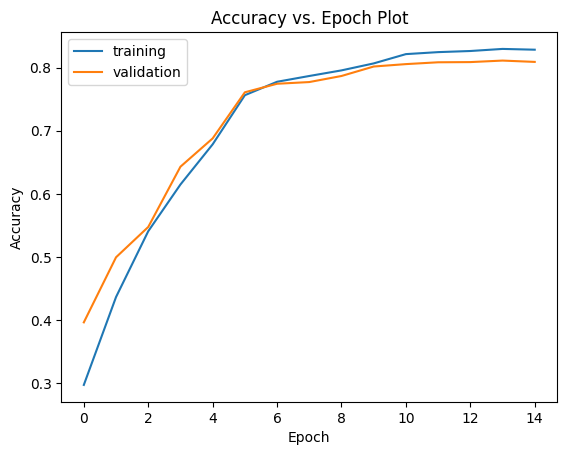

In [12]:
import matplotlib.pyplot as plt
# make plot for accuracy

plt.plot(train_acc, label="training")
plt.plot(val_acc, label="validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs. Epoch Plot")
plt.legend()
plt.savefig('./images/baseline_accuracy_plot.png')
plt.show()

## Conclusion/Dicussion/Intepretation

- CIFAR stem + skips:
    - Test acc: 83.29%
    - Runtime: 239m 15s

- CIFAR stem + no skips:
    - Test acc: 81.35%
    - Runtime: 209m 7s

- Accuracy drop: -1.94 percentage points

- Removing skip connections reduced test accuracy from 83.29% to 81.35%.
This suggests residual connections improve optimization/generalization, but the effect is moderate at ResNet-18 depth.
A deeper network would likely show a larger degradation without skip connections.

## Save Model

In [14]:
# Save the weights to a file
torch.save(no_skip_model.state_dict(), './model-weights/no_skip_resnet18.pth')